<a href="https://colab.research.google.com/github/DarthAsclepio/TELCOM-X-PT2/blob/main/TELCOM_X_PT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CARGA DE BIBLIOTECAS**

In [90]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import requests
import pandas as pd
import numpy as np
import json
import os
import pickle


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.patches import Patch

# **CARGA DE LOS DATOS**

In [91]:
url = "https://raw.githubusercontent.com/DarthAsclepio/TELCOM_X_PT1_ALURA/refs/heads/main/TELCOM_DATOS_CLEAN.csv"

df = pd.read_csv(url, sep=",")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# **LIMPIANDO LOS DATOS**

## DIAGNOSTICO INICIAL

In [92]:
diagnostico_inicial = pd.DataFrame({
    "Métrica": [
        "Filas iniciales",
        "Columnas iniciales",
        "Nulos totales",
        "Duplicados (con ID)"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

display(diagnostico_inicial)

,Métrica,Valor
0,Filas iniciales,7043
1,Columnas iniciales,23
2,Nulos totales,0
3,Duplicados (con ID),0


## ESTANDARIZAMOS LAS CATEGORIAS

In [93]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

cambios_categorias = []

for col in cols_to_fix:
    if col in df.columns:
        antes = df[col].value_counts(dropna=False)
        df[col] = df[col].replace({'No internet service': 'No'})
        despues = df[col].value_counts(dropna=False)

        cambios_categorias.append({
            "Columna": col,
            "Valores únicos antes": len(antes),
            "Valores únicos después": len(despues),
            "Cambio aplicado": "Sí"
        })

tabla_cambios = pd.DataFrame(cambios_categorias)
display(tabla_cambios)

,Columna,Valores únicos antes,Valores únicos después,Cambio aplicado
0,OnlineSecurity,3,2,Sí
1,OnlineBackup,3,2,Sí
2,DeviceProtection,3,2,Sí
3,TechSupport,3,2,Sí
4,StreamingTV,3,2,Sí
5,StreamingMovies,3,2,Sí


## ELIMINACION DE LOS ID Y DE LOS DUPLICADOS

In [94]:
columnas_antes = df.shape[1]

if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])
    id_eliminado = "CustomerID"
elif 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])
    id_eliminado = "customerID"
else:
    id_eliminado = "No encontrado"

columnas_despues = df.shape[1]

duplicados_sin_id = df.duplicated().sum()
filas_antes = df.shape[0]

if duplicados_sin_id > 0:
    df = df.drop_duplicates()
    filas_despues = df.shape[0]
else:
    filas_despues = filas_antes

tabla_duplicados = pd.DataFrame({
    "Métrica": [
        "Columna ID eliminada",
        "Columnas antes",
        "Columnas después",
        "Duplicados encontrados",
        "Filas antes limpieza",
        "Filas después limpieza"
    ],
    "Valor": [
        id_eliminado,
        columnas_antes,
        columnas_despues,
        duplicados_sin_id,
        filas_antes,
        filas_despues
    ]
})

display(tabla_duplicados)

,Métrica,Valor
0,Columna ID eliminada,customerID
1,Columnas antes,23
2,Columnas después,22
3,Duplicados encontrados,26
4,Filas antes limpieza,7043
5,Filas después limpieza,7017


## REPORTE FINAL DE NULOS

In [95]:
reporte_nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Nulos', ascending=False)

display(reporte_nulos)

df_numeric = df.select_dtypes(include=["int64", "float64"]).copy()

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

,Nulos,Porcentaje (%)
Churn,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## RESUMEN DE LOS DATOS

In [96]:
resumen_final = pd.DataFrame({

    "Métrica": [
        "Filas finales",
        "Columnas finales",
        "Nulos totales finales",
        "Duplicados totales finales"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]

})

display(resumen_final)

,Métrica,Valor
0,Filas finales,7017
1,Columnas finales,22
2,Nulos totales finales,0
3,Duplicados totales finales,0


## CORRELACIÓN DE VARIABLES

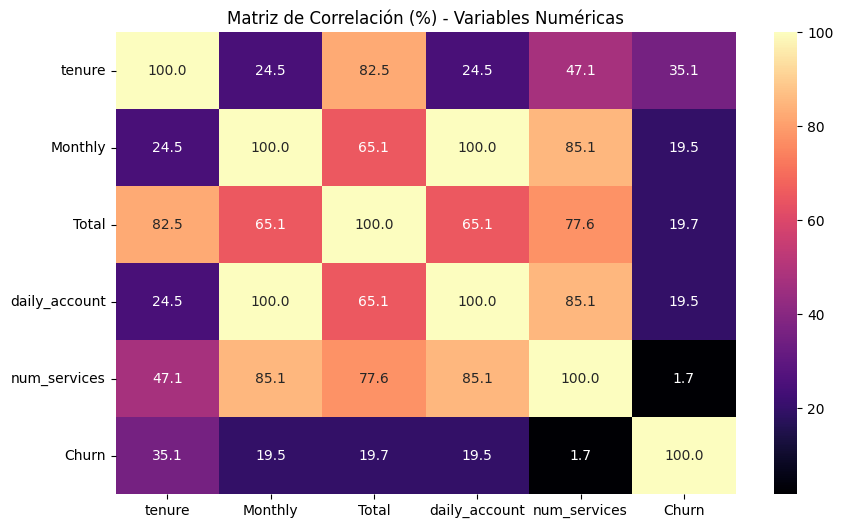


 Máximo porcentaje de correlación por variable:
Monthly          100.000000
daily_account    100.000000
num_services      85.133368
tenure            82.548978
Total             82.548978
Churn             35.108540
dtype: float64

 Porcentaje de correlación de cada variable con Churn:
tenure           35.108540
Total            19.675708
daily_account    19.484244
Monthly          19.484244
num_services      1.690365
Name: Churn, dtype: float64


In [97]:
corr_matrix = df_numeric.corr()


corr_percent = corr_matrix.abs() * 100





plt.figure(figsize=(10,6))
sns.heatmap(corr_percent, annot=True, cmap="magma", fmt=".1f")
plt.title("Matriz de Correlación (%) - Variables Numéricas")
plt.show()



np.fill_diagonal(corr_percent.values, np.nan)

max_corr_per_var = corr_percent.max().sort_values(ascending=False)

print("\n Máximo porcentaje de correlación por variable:")
print(max_corr_per_var)



if "Churn" in corr_percent.columns:
    churn_corr = corr_percent["Churn"].drop("Churn").sort_values(ascending=False)

    print("\n Porcentaje de correlación de cada variable con Churn:")
    print(churn_corr)

# **FEATURE ENGINEERING**

In [98]:
if 'ChargesDaily' in df.columns:
    df.drop(columns=['ChargesDaily'], inplace=True)

In [99]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]


def count_services(row):
    count = 0



    if row['InternetService'] != 'No':
        count += 1



    for col in service_cols:
        if col != 'InternetService' and row[col] == 'Yes':
            count += 1

    return count




df['num_services'] = df.apply(count_services, axis=1)

print(f"Variable 'num_services' creada. Rango: {df['num_services'].min()} - {df['num_services'].max()}")

Variable 'num_services' creada. Rango: 1 - 9


# **Análisis categórico y Test Chi²**

In [100]:
categorical_cols = df.select_dtypes(include=["object"]).columns

if "Churn" in categorical_cols:
    categorical_cols = categorical_cols.drop("Churn")

for col in categorical_cols:
    print(f"\n Análisis de variable: {col}")

    tabla_prop = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    display(tabla_prop.round(2))


 Análisis de variable: gender


Churn,No,Yes
gender,,
Female,73.20,26.80
Male,73.95,26.05



 Análisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
Unknown,73.58,26.42



 Análisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.39,42.61
One year,88.73,11.27
Two year,97.17,2.83



 Análisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.70,16.30
Yes,66.62,33.38



 Análisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.90,45.10
Mailed check,81.08,18.92


In [101]:
df_rank = df.copy()

df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})



categorical_cols = df_rank.select_dtypes(include=["object"]).columns



le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])



X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]



chi_scores, p_values = chi2(X_cat, y)



chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values,
    "p-value_decimal": [f"{p:.6f}" for p in p_values],
    "Significancia": ["Significativo" if p < 0.05 else "No Significativo" for p in p_values]
})



significant_vars = chi_df[chi_df["p-value"] > 0.05]
print("\nVariables con baja relevancia p-value > 0.05:")
print(significant_vars[["Variable", "p-value"]])



chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


Variables con baja relevancia p-value > 0.05:
       Variable   p-value
0        gender  0.618588
4  PhoneService  0.755459


,Variable,Chi2 Score,p-value,p-value_decimal,Significancia
13,Contract,1106.715740,1.146202e-242,0.000000,Significativo
7,OnlineSecurity,144.861590,2.302613e-33,0.000000,Significativo
10,TechSupport,133.192256,8.206690e-31,0.000000,Significativo
3,Dependents,130.644335,2.961931e-30,0.000000,Significativo
14,PaperlessBilling,103.604782,2.469804e-24,0.000000,Significativo
2,Partner,80.425016,3.019483e-19,0.000000,Significativo
15,PaymentMethod,57.293118,3.754667e-14,0.000000,Significativo
8,OnlineBackup,29.877605,4.601977e-08,0.000000,Significativo
9,DeviceProtection,19.139160,1.215257e-05,0.000012,Significativo
11,StreamingTV,18.537090,1.666300e-05,0.000017,Significativo


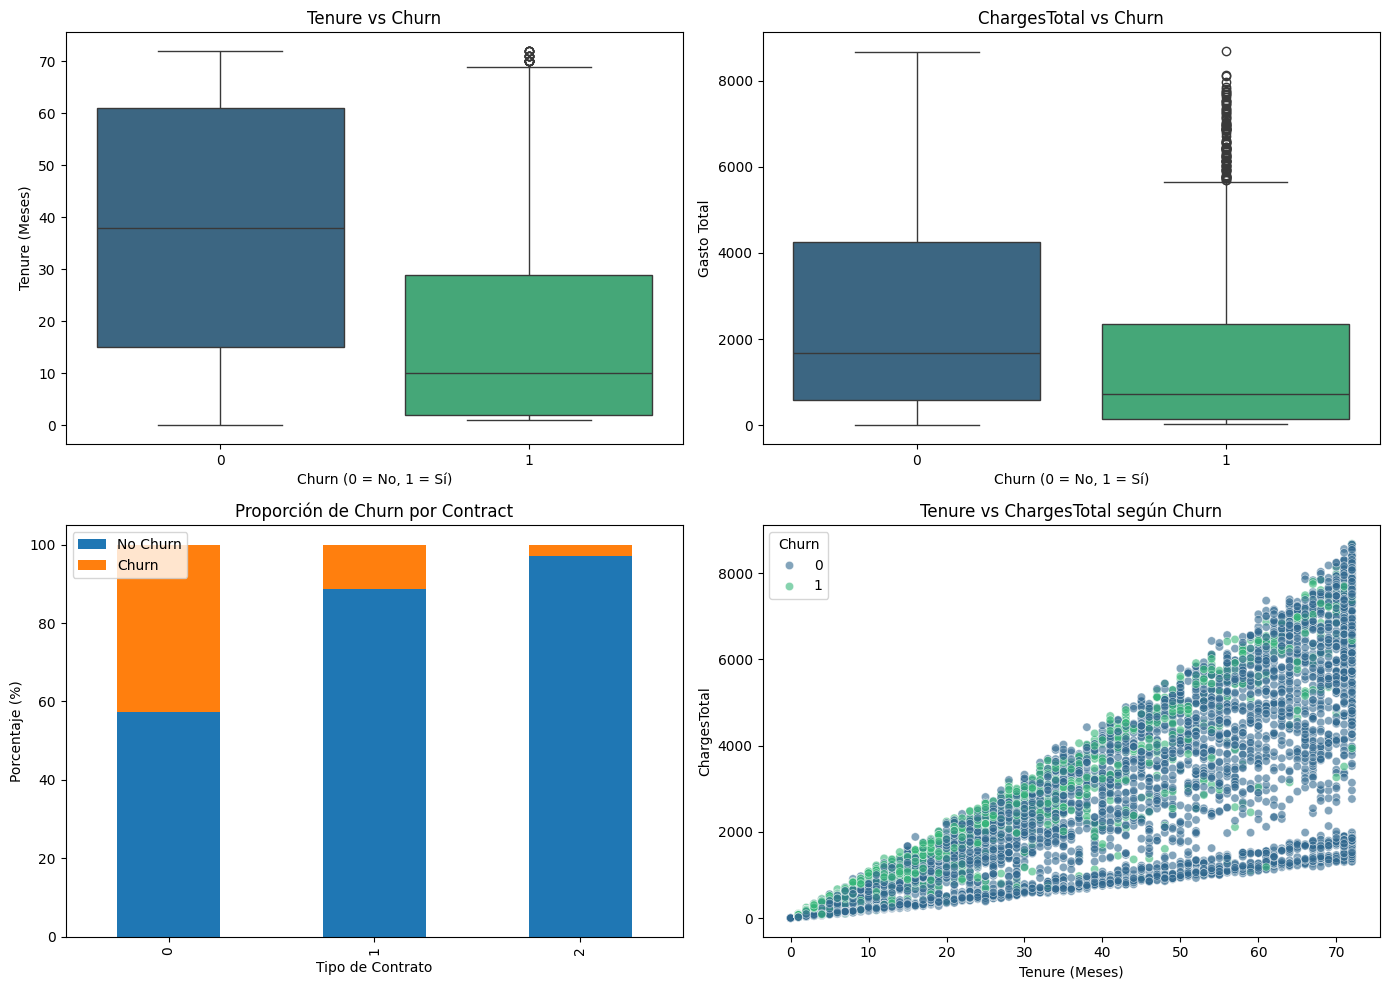

In [102]:

os.makedirs("imgs", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.boxplot(
    ax=axes[0, 0],
    x="Churn",
    y="tenure",
    data=df_rank,
    palette='viridis'
)

axes[0, 0].set_title("Tenure vs Churn")
axes[0, 0].set_xlabel("Churn (0 = No, 1 = Sí)")
axes[0, 0].set_ylabel("Tenure (Meses)")



sns.boxplot(
    ax=axes[0, 1],
    x="Churn",
    y="Total",
    data=df_rank,
    palette='viridis'
)

axes[0, 1].set_title("ChargesTotal vs Churn")
axes[0, 1].set_xlabel("Churn (0 = No, 1 = Sí)")
axes[0, 1].set_ylabel("Gasto Total")





contract_churn = pd.crosstab(
    df_rank["Contract"],
    df_rank["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 0],
)

axes[1, 0].set_title("Proporción de Churn por Contract")
axes[1, 0].set_ylabel("Porcentaje (%)")
axes[1, 0].set_xlabel("Tipo de Contrato")
axes[1, 0].legend(["No Churn", "Churn"])





sns.scatterplot(
    ax=axes[1, 1],
    x="tenure",
    y="Total",
    hue="Churn",
    data=df_rank,
    alpha=0.6,
    palette='viridis'
)

axes[1, 1].set_title("Tenure vs ChargesTotal según Churn")
axes[1, 1].set_xlabel("Tenure (Meses)")
axes[1, 1].set_ylabel("ChargesTotal")

plt.tight_layout()

plt.savefig("imgs/analisis_dirigido_churn.png", dpi=300, bbox_inches="tight")

plt.show()


In [116]:
url = "https://raw.githubusercontent.com/DarthAsclepio/TELCOM_X_PT1_ALURA/refs/heads/main/TELCOM_DATOS_CLEAN.csv"
df = pd.read_csv(url, sep=",")

cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].replace({'No internet service': 'No'})


if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])
elif 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

duplicados_sin_id = df.duplicated().sum()
if duplicados_sin_id > 0:
    df = df.drop_duplicates()

service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

def count_services(row):
    count = 0
    if row['InternetService'] != 'No':
        count += 1
    for col in service_cols:
        if col != 'InternetService' and row[col] == 'Yes':
            count += 1
    return count

df['num_services'] = df.apply(count_services, axis=1)


print("DataFrame 'df' re-loaded and re-processed successfully.")
df.info()

DataFrame 'df' re-loaded and re-processed successfully.
<class 'pandas.core.frame.DataFrame'>
Index: 7017 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7017 non-null   object 
 1   gender            7017 non-null   object 
 2   SeniorCitizen     7017 non-null   object 
 3   Partner           7017 non-null   object 
 4   Dependents        7017 non-null   object 
 5   tenure            7017 non-null   int64  
 6   PhoneService      7017 non-null   object 
 7   MultipleLines     7017 non-null   object 
 8   InternetService   7017 non-null   object 
 9   OnlineSecurity    7017 non-null   object 
 10  OnlineBackup      7017 non-null   object 
 11  DeviceProtection  7017 non-null   object 
 12  TechSupport       7017 non-null   object 
 13  StreamingTV       7017 non-null   object 
 14  StreamingMovies   7017 non-null   object 
 15  Contract          7017 non-null   obje

In [115]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df.dropna(subset=['Churn'], inplace=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=5
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.176,
    stratify=y_temp,
    random_state=5
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

numeric_features = [
    "tenure",
    "Monthly",
    "Total",
    "num_services"
]

categorical_features = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

Train shape: (4914, 21)
Validation shape: (1050, 21)
Test shape: (1053, 21)


In [105]:
print(df["Churn"].unique())
print(df["Churn"].dtype)

[0 1]
int64


In [106]:
df_balance = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
})

df_balance

,Train,Validation,Test
Churn,,,
0,0.735653,0.73619,0.735992
1,0.264347,0.26381,0.264008


In [107]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_df.head()

,num__tenure,num__Monthly,num__Total,num__num_services,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__DeviceProtection_Yes,cat__TechSupport_Yes,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
3245,0.909722,-1.528797,-0.566756,-1.377574,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2765,0.460717,-1.322237,-0.529738,-0.946072,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1651,0.909722,-1.495481,-0.500067,-1.377574,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6650,1.603638,0.656739,1.689500,1.642937,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6147,0.011712,1.153149,0.442479,0.779934,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [108]:
def mostrar_distribucion(y_train, y_val, y_test):
    for nombre, y in zip(["Train", "Validation", "Test"], [y_train, y_val, y_test]):
        total = len(y)
        counts = y.value_counts()
        porcentaje = (counts / total * 100).round(2)
        print(f"--- {nombre} ---")
        for clase, pct in zip(counts.index, porcentaje):
            print(f"Clase {clase}: {counts[clase]} ({pct}%)")
        print()

mostrar_distribucion(y_train, y_val, y_test)

--- Train ---
Clase 0: 3615 (73.57%)
Clase 1: 1299 (26.43%)

--- Validation ---
Clase 0: 773 (73.62%)
Clase 1: 277 (26.38%)

--- Test ---
Clase 0: 775 (73.6%)
Clase 1: 278 (26.4%)



# **MODELOS PREDICTIVOS**

In [109]:
lr_model = LogisticRegression(max_iter=1000, random_state=5)


lr_model.fit(X_train_processed, y_train)



train_score = lr_model.score(X_train_processed, y_train)
val_score = lr_model.score(X_val_processed, y_val)

print("=" * 50)
print("LOGISTIC REGRESSION - BASELINE")
print("=" * 50)
print(f"Train Score: {train_score:.4f}")
print(f"Validation Score: {val_score:.4f}")
print("=" * 50)




y_val_pred = lr_model.predict(X_val_processed)


print("\nAccuracy (Validation):", accuracy_score(y_val, y_val_pred))
print("Recall (Validation):", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))





cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)
print("-" * 35)

LOGISTIC REGRESSION - BASELINE
Train Score: 0.8081
Validation Score: 0.7924

Accuracy (Validation): 0.7923809523809524
Recall (Validation): 0.48736462093862815
F1-score: 0.5532786885245902

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       773
           1       0.64      0.49      0.55       277

    accuracy                           0.79      1050
   macro avg       0.74      0.69      0.71      1050
weighted avg       0.78      0.79      0.78      1050


Confusion Matrix:
 [[697  76]
 [142 135]]
-----------------------------------


In [110]:
models = {



    "Logistic_Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=5
        ))
    ]),



    "Random_Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=5,
            n_jobs=-1
        ))
    ]),



    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=5,
            n_jobs=-1
        ))
    ]),



    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            verbose=-1,
            random_state=5,
            n_jobs=-1
        ))
    ]),



    "MLP": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(100,),
            activation='relu',
            solver='adam',
            max_iter=200,
            random_state=5
        ))
    ])
}




results = []

print("=" * 70)
print("COMPARATIVA DE MODELOS - CONFIGURACIÓN BASE")


for name, pipeline in models.items():



    pipeline.fit(X_train, y_train)


    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)


    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)


    results.append({
        "Modelo": name,
        "Train_Acc": train_acc,
        "Val_Acc": val_acc,
        "Recall": val_recall,
        "Precision": val_precision,
        "F1_Score": val_f1
    })


    print(f"\n{'-' * 70}")
    print(f"{name}")
    print(f"{'-' * 70}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val Recall:     {val_recall:.4f}")
    print(f"Val Precision:  {val_precision:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")


    cm = confusion_matrix(y_val, y_val_pred)
    print(f"\nMatriz de Confusión:")
    print(f"              Predicho")
    print(f"              No(0)   Yes(1)")
    print(f"Real No(0)   {cm[0,0]:5d}    {cm[0,1]:5d}")
    print(f"     Yes(1)  {cm[1,0]:5d}    {cm[1,1]:5d}")




results_df = pd.DataFrame(results)

results_df = results_df.sort_values("F1_Score", ascending=False)
results_recall = results_df.sort_values("Recall", ascending=False)

print("\n" + "=" * 70)
print("RANKING DE MODELOS BASE por F1-Score")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

print("RANKING DE MODELOS BASE por Recall")
print("=" * 70)
print(results_recall.to_string(index=False))
print("=" * 70)


best_model = results_df.iloc[0]["Modelo"]
best_f1 = results_df.iloc[0]["F1_Score"]
best_recall = results_recall.iloc[0]["Recall"]
print(f"\nMEJOR MODELO BASE: {best_model} (F1-Score: {best_f1:.4f})")
print(f"MEJOR MODELO BASE: {best_model} (Recall: {best_recall:.4f})")

COMPARATIVA DE MODELOS - CONFIGURACIÓN BASE

----------------------------------------------------------------------
Logistic_Regression
----------------------------------------------------------------------
Train Accuracy: 0.8081
Val Accuracy:   0.7924
Val Recall:     0.4874
Val Precision:  0.6398
Val F1-Score:   0.5533

Matriz de Confusión:
              Predicho
              No(0)   Yes(1)
Real No(0)     697       76
     Yes(1)    142      135

----------------------------------------------------------------------
Random_Forest
----------------------------------------------------------------------
Train Accuracy: 0.9984
Val Accuracy:   0.7810
Val Recall:     0.4404
Val Precision:  0.6193
Val F1-Score:   0.5148

Matriz de Confusión:
              Predicho
              No(0)   Yes(1)
Real No(0)     698       75
     Yes(1)    155      122

----------------------------------------------------------------------
XGBoost
------------------------------------------------------------------

In [111]:
print("\n" + "=" * 70)
print("DIAGNÓSTICO DE SOBREAJUSTE (Train vs Val Accuracy)")
print("=" * 70)

for idx, row in results_df.iterrows():
    gap = row["Train_Acc"] - row["Val_Acc"]
    if gap > 0.10:
        status = "SOBREAJUSTE (gap > 0.10)"
    elif gap > 0.05:
        status = "Leve - sobreajuste (gap > 0.05)"
    else:
        status = "Bien - generalizado"
    print(f"{row['Modelo']:<25} Gap: {gap:.4f} - {status}")


DIAGNÓSTICO DE SOBREAJUSTE (Train vs Val Accuracy)
Logistic_Regression       Gap: 0.0157 - Bien - generalizado
MLP                       Gap: 0.0505 - Leve - sobreajuste (gap > 0.05)
LightGBM                  Gap: 0.0733 - Leve - sobreajuste (gap > 0.05)
XGBoost                   Gap: 0.0839 - Leve - sobreajuste (gap > 0.05)
Random_Forest             Gap: 0.2174 - SOBREAJUSTE (gap > 0.10)


## COMPARANDO 5 MODELOS

CONFIGURACIÓN INICIAL
Clase No Churn (0): 3615 muestras
Clase Churn (1):    1299 muestras
Ratio desbalance:    2.78

ENTRENAMIENTO Y EVALUACIÓN DE MODELOS CON BALANCE

-> Entrenando Logistic_Regression...

----------------------------------------------------------------------
Logistic_Regression
----------------------------------------------------------------------
Train Accuracy: 0.7493
Val Accuracy:   0.7438
Val Recall:     0.7726
Val Precision:  0.5095
Val F1-Score:   0.6141


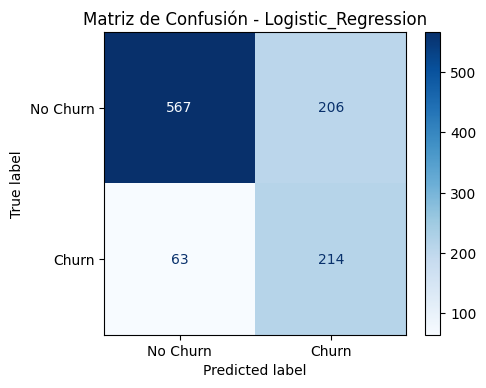


-> Entrenando Random_Forest...

----------------------------------------------------------------------
Random_Forest
----------------------------------------------------------------------
Train Accuracy: 0.7896
Val Accuracy:   0.7581
Val Recall:     0.7365
Val Precision:  0.5299
Val F1-Score:   0.6163


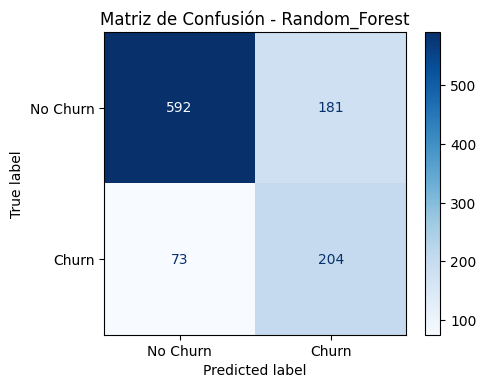


-> Entrenando XGBoost...

----------------------------------------------------------------------
XGBoost
----------------------------------------------------------------------
Train Accuracy: 0.8014
Val Accuracy:   0.7495
Val Recall:     0.7220
Val Precision:  0.5181
Val F1-Score:   0.6033


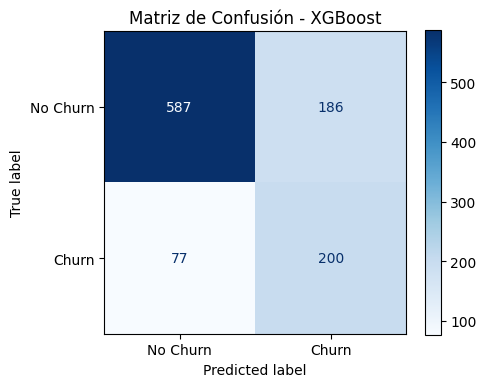


-> Entrenando LightGBM...

----------------------------------------------------------------------
LightGBM
----------------------------------------------------------------------
Train Accuracy: 0.8394
Val Accuracy:   0.7514
Val Recall:     0.6859
Val Precision:  0.5220
Val F1-Score:   0.5928


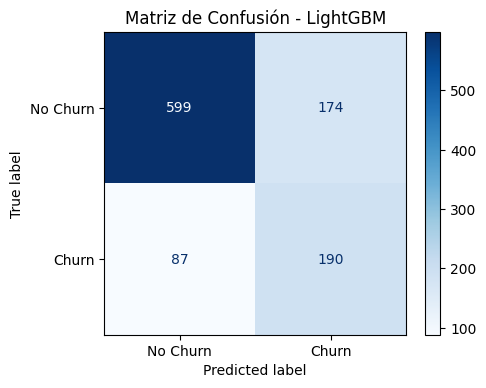


-> Entrenando MLP_SMOTE...

----------------------------------------------------------------------
MLP_SMOTE
----------------------------------------------------------------------
Train Accuracy: 0.7613
Val Accuracy:   0.7457
Val Recall:     0.7581
Val Precision:  0.5122
Val F1-Score:   0.6114


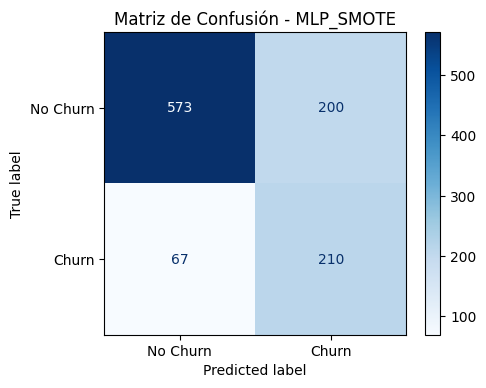


RANKING DE MODELOS CON BALANCE (por Recall)
             Modelo   Recall  Precision  F1_Score  Val_Acc
Logistic_Regression 0.772563   0.509524  0.614060 0.743810
          MLP_SMOTE 0.758123   0.512195  0.611354 0.745714
      Random_Forest 0.736462   0.529870  0.616314 0.758095
            XGBoost 0.722022   0.518135  0.603318 0.749524
           LightGBM 0.685921   0.521978  0.592824 0.751429
MEJOR RECALL: Logistic_Regression (Recall: 0.7726)

RANKING DE MODELOS CON BALANCE (por F1-Score)
             Modelo  F1_Score   Recall  Precision  Val_Acc
      Random_Forest  0.616314 0.736462   0.529870 0.758095
Logistic_Regression  0.614060 0.772563   0.509524 0.743810
          MLP_SMOTE  0.611354 0.758123   0.512195 0.745714
            XGBoost  0.603318 0.722022   0.518135 0.749524
           LightGBM  0.592824 0.685921   0.521978 0.751429
MEJOR F1-SCORE: Random_Forest (F1: 0.6163)

DIAGNÓSTICO DE SOBREAJUSTE MODELOS CON BALANCE (Train vs Val Accuracy)
Logistic_Regression       Gap: 0.0

In [128]:
warnings.filterwarnings('ignore')

neg_class = (y_train == 0).sum()
pos_class = (y_train == 1).sum()
scale_weight = neg_class / pos_class

print("=" * 70)
print("CONFIGURACIÓN INICIAL")
print("=" * 70)
print(f"Clase No Churn (0): {neg_class} muestras")
print(f"Clase Churn (1):    {pos_class} muestras")
print(f"Ratio desbalance:    {scale_weight:.2f}")
print("=" * 70)

models = {

    "Logistic_Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            C=0.1,
            penalty='l2',
            class_weight='balanced',
            solver='lbfgs',
            random_state=5
        ))
    ]),

    "Random_Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            max_features='sqrt',
            class_weight='balanced',
            random_state=5
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_weight,
            random_state=5
        ))
    ]),

    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=5,
            verbose=-1
        ))
    ]),

    "MLP_SMOTE": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            random_state=5,
            sampling_strategy='auto',
            k_neighbors=5
        )),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            solver='adam',
            alpha=0.001,
            learning_rate='adaptive',
            learning_rate_init=0.00008,
            batch_size=64,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            max_iter=800,
            random_state=5
        ))
    ])
}


results = []
pipelines_fitted = {}

print("\n" + "=" * 70)
print("ENTRENAMIENTO Y EVALUACIÓN DE MODELOS CON BALANCE")
print("=" * 70)

for name, pipeline in models.items():

    print(f"\n-> Entrenando {name}...")
    pipeline.fit(X_train, y_train)
    pipelines_fitted[name] = pipeline

    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    results.append({
        "Modelo": name,
        "Train_Acc": train_acc,
        "Val_Acc": val_acc,
        "Recall": val_recall,
        "Precision": val_precision,
        "F1_Score": val_f1
    })

    print(f"\n{'-' * 70}")
    print(f"{name}")
    print(f"{'-' * 70}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val Recall:     {val_recall:.4f}")
    print(f"Val Precision:  {val_precision:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")

    cm = confusion_matrix(y_val, y_val_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f"Matriz de Confusión - {name}")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(f"imgs/matriz_confusion_{name}_balanced")
    plt.show()

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("RANKING DE MODELOS CON BALANCE (por Recall)")
print("=" * 70)
results_recall = results_df.sort_values("Recall", ascending=False)
print(results_recall[["Modelo", "Recall", "Precision", "F1_Score", "Val_Acc"]].to_string(index=False))
print("=" * 70)
best_recall_model = results_recall.iloc[0]["Modelo"]
best_recall = results_recall.iloc[0]["Recall"]
print(f"MEJOR RECALL: {best_recall_model} (Recall: {best_recall:.4f})")

print("\n" + "=" * 70)
print("RANKING DE MODELOS CON BALANCE (por F1-Score)")
print("=" * 70)
results_f1 = results_df.sort_values("F1_Score", ascending=False)
print(results_f1[["Modelo", "F1_Score", "Recall", "Precision", "Val_Acc"]].to_string(index=False))
print("=" * 70)
best_f1_model = results_f1.iloc[0]["Modelo"]
best_f1 = results_f1.iloc[0]["F1_Score"]
print(f"MEJOR F1-SCORE: {best_f1_model} (F1: {best_f1:.4f})")

print("\n" + "=" * 70)
print("DIAGNÓSTICO DE SOBREAJUSTE MODELOS CON BALANCE (Train vs Val Accuracy)")
print("=" * 70)

for idx, row in results_df.iterrows():
    gap = row["Train_Acc"] - row["Val_Acc"]
    if gap > 0.10:
        status = "SOBREAJUSTE (gap > 0.10)"
    elif gap > 0.05:
        status = "Leve sobreajuste (gap > 0.05)"
    else:
        status = "Bien generalizado"
    print(f"{row['Modelo']:<25} Gap: {gap:.4f} - {status}")

print("\n" + "=" * 70)
print("RESUMEN DE TÉCNICAS DE BALANCEO APLICADAS")
print("=" * 70)
print(f"{('Modelo'):<25} {('Técnica'):<30} {('Parámetro')}")
print("-" * 70)
print(f"{('Logistic_Regression'):<25} {('class_weight'):<30} {('balanced + C=0.1')}")
print(f"{('Random_Forest'):<25} {('class_weight'):<30} {('balanced_subsample + depth=8')}")
print(f"{('XGBoost'):<25} {('scale_pos_weight'):<30} {f'{scale_weight:.2f} + reg_alpha=0.1'}")
print(f"{('LightGBM'):<25} {('class_weight'):<30} {('balanced + reg_alpha=0.1')}")
print(f"{('MLP_SMOTE'):<25} {('SMOTE'):<30} {('auto + alpha=0.01')}")
print("=" * 70)

# **VALIDACIÓN CRUZADA**

CONFIGURACIÓN DE VALIDACIÓN CRUZADA
Número de folds:        5
Estrategia:             StratifiedKFold (mantiene proporción de clases)
Clase No Churn (0):     3615 muestras (73.6%)
Clase Churn (1):        1299 muestras (26.4%)
Ratio desbalance:       2.78

EJECUTANDO CROSS VALIDATION

-> Procesando Logistic_Regression...
   ✓ CV F1:      0.6225 (±0.0054)
   ✓ CV Recall:  0.7929 (±0.0278)
   ✓ CV ROC-AUC: 0.8439 (±0.0063)
   ✓ Val F1:     0.6141
   ✓ Val Recall: 0.7726

-> Procesando Random_Forest...
   ✓ CV F1:      0.6287 (±0.0110)
   ✓ CV Recall:  0.7637 (±0.0168)
   ✓ CV ROC-AUC: 0.8470 (±0.0080)
   ✓ Val F1:     0.6163
   ✓ Val Recall: 0.7365

-> Procesando XGBoost...
   ✓ CV F1:      0.6239 (±0.0175)
   ✓ CV Recall:  0.7729 (±0.0244)
   ✓ CV ROC-AUC: 0.8419 (±0.0117)
   ✓ Val F1:     0.6033
   ✓ Val Recall: 0.7220

-> Procesando LightGBM...
   ✓ CV F1:      0.6101 (±0.0215)
   ✓ CV Recall:  0.7275 (±0.0317)
   ✓ CV ROC-AUC: 0.8353 (±0.0120)
   ✓ Val F1:     0.5928
   ✓ Val Recall: 

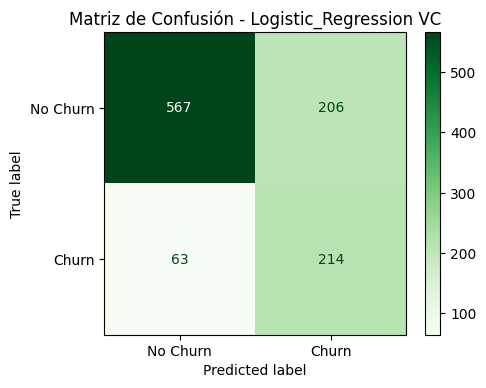


Logistic_Regression:
              Predicho
              No(0)   Yes(1)
Real No(0)     567      206
     Yes(1)     63      214


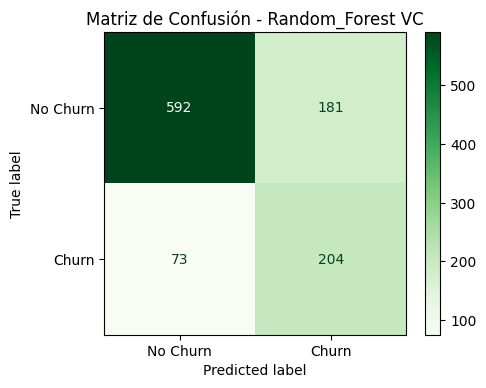


Random_Forest:
              Predicho
              No(0)   Yes(1)
Real No(0)     592      181
     Yes(1)     73      204


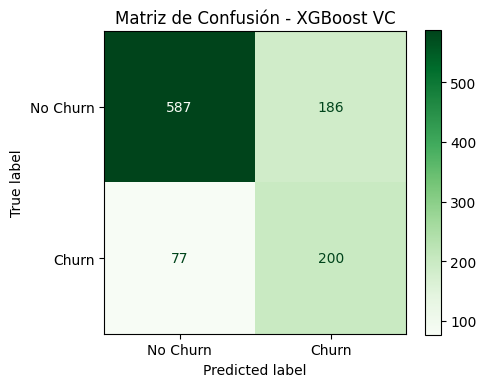


XGBoost:
              Predicho
              No(0)   Yes(1)
Real No(0)     587      186
     Yes(1)     77      200


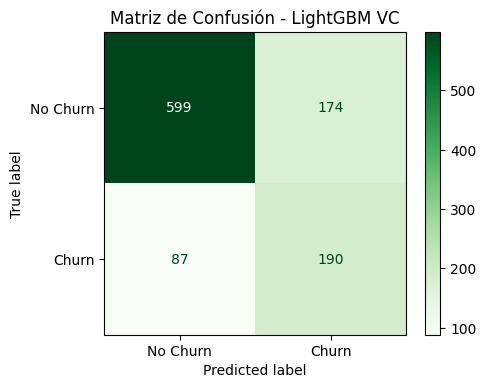


LightGBM:
              Predicho
              No(0)   Yes(1)
Real No(0)     599      174
     Yes(1)     87      190


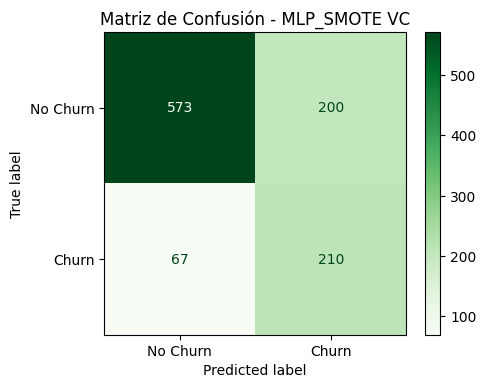


MLP_SMOTE:
              Predicho
              No(0)   Yes(1)
Real No(0)     573      200
     Yes(1)     67      210


In [129]:
warnings.filterwarnings('ignore')




neg_class = (y_train == 0).sum()
pos_class = (y_train == 1).sum()
scale_weight = neg_class / pos_class

CV_FOLDS = 5
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=5)

print("=" * 70)
print("CONFIGURACIÓN DE VALIDACIÓN CRUZADA")
print("=" * 70)
print(f"Número de folds:        {CV_FOLDS}")
print(f"Estrategia:             StratifiedKFold (mantiene proporción de clases)")
print(f"Clase No Churn (0):     {neg_class} muestras ({neg_class/(neg_class+pos_class)*100:.1f}%)")
print(f"Clase Churn (1):        {pos_class} muestras ({pos_class/(neg_class+pos_class)*100:.1f}%)")
print(f"Ratio desbalance:       {scale_weight:.2f}")
print("=" * 70)



models = {



    "Logistic_Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            C=0.1,
            penalty='l2',
            class_weight='balanced',
            solver='lbfgs',
            random_state=5
        ))
    ]),



    "Random_Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            max_features='sqrt',
            class_weight='balanced',
            random_state=5,
        ))
    ]),


    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_weight,
            random_state=5,
        ))
    ]),

    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=5,
            verbose=-1
        ))
    ]),




    "MLP_SMOTE": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            random_state=5,
            sampling_strategy='auto',
            k_neighbors=5
        )),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            solver='adam',
            alpha=0.001,
            learning_rate='adaptive',
            learning_rate_init=0.00008,
            batch_size=64,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            max_iter=800,
            random_state=5
        ))
    ])
}




scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}




print("\n" + "=" * 70)
print("EJECUTANDO CROSS VALIDATION")
print("=" * 70)

cv_results = []
pipelines_fitted = {}

for name, pipeline in models.items():

    print(f"\n-> Procesando {name}...")


    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )


    pipeline.fit(X_train, y_train)
    pipelines_fitted[name] = pipeline


    y_val_pred = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1] if hasattr(pipeline, "predict_proba") else None


    val_acc = accuracy_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else None


    cv_results.append({
        "Modelo": name,

        "CV_Train_Acc_Mean": cv_scores['train_accuracy'].mean(),
        "CV_Train_Acc_Std": cv_scores['train_accuracy'].std(),

        "CV_Val_Acc_Mean": cv_scores['test_accuracy'].mean(),
        "CV_Val_Acc_Std": cv_scores['test_accuracy'].std(),
        "CV_Recall_Mean": cv_scores['test_recall'].mean(),
        "CV_Recall_Std": cv_scores['test_recall'].std(),
        "CV_Precision_Mean": cv_scores['test_precision'].mean(),
        "CV_Precision_Std": cv_scores['test_precision'].std(),
        "CV_F1_Mean": cv_scores['test_f1'].mean(),
        "CV_F1_Std": cv_scores['test_f1'].std(),
        "CV_ROC_AUC_Mean": cv_scores['test_roc_auc'].mean(),
        "CV_ROC_AUC_Std": cv_scores['test_roc_auc'].std(),

        "Val_Acc": val_acc,
        "Val_Recall": val_recall,
        "Val_Precision": val_precision,
        "Val_F1": val_f1,
        "Val_ROC_AUC": val_roc_auc
    })


    print(f"   ✓ CV F1:      {cv_scores['test_f1'].mean():.4f} (±{cv_scores['test_f1'].std():.4f})")
    print(f"   ✓ CV Recall:  {cv_scores['test_recall'].mean():.4f} (±{cv_scores['test_recall'].std():.4f})")
    print(f"   ✓ CV ROC-AUC: {cv_scores['test_roc_auc'].mean():.4f} (±{cv_scores['test_roc_auc'].std():.4f})")
    print(f"   ✓ Val F1:     {val_f1:.4f}")
    print(f"   ✓ Val Recall: {val_recall:.4f}")


cv_df = pd.DataFrame(cv_results)




print("\n" + "=" * 70)
print("MATRICES DE CONFUSIÓN CV")
print("=" * 70)

for name, pipeline in pipelines_fitted.items():

    y_val_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_val_pred)


    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, cmap='Greens', values_format='d')
    ax.set_title(f"Matriz de Confusión - {name} VC")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(f"imgs/confusion_matrix_{name}_VC.png")
    plt.show()


    print(f"\n{name}:")
    print(f"              Predicho")
    print(f"              No(0)   Yes(1)")
    print(f"Real No(0)   {cm[0,0]:5d}    {cm[0,1]:5d}")
    print(f"     Yes(1)  {cm[1,0]:5d}    {cm[1,1]:5d}")

In [130]:
print("\n" + "=" * 70)
print("RANKING POR F1-SCORE (Cross Validation)")
print("=" * 70)
cv_df_f1 = cv_df.sort_values("CV_F1_Mean", ascending=False)
print(cv_df_f1[["Modelo", "CV_F1_Mean", "CV_F1_Std", "CV_Recall_Mean", "CV_ROC_AUC_Mean"]].to_string(index=False))

print("\n" + "=" * 70)
print("RANKING POR RECALL (Cross Validation)")
print("=" * 70)
cv_df_recall = cv_df.sort_values("CV_Recall_Mean", ascending=False)
print(cv_df_recall[["Modelo", "CV_Recall_Mean", "CV_Recall_Std", "CV_F1_Mean", "CV_ROC_AUC_Mean"]].to_string(index=False))

print("\n" + "=" * 70)
print("RANKING POR ROC-AUC (Cross Validation)")
print("=" * 70)
cv_df_auc = cv_df.sort_values("CV_ROC_AUC_Mean", ascending=False)
print(cv_df_auc[["Modelo", "CV_ROC_AUC_Mean", "CV_ROC_AUC_Std", "CV_F1_Mean", "CV_Recall_Mean"]].to_string(index=False))


RANKING POR F1-SCORE (Cross Validation)
             Modelo  CV_F1_Mean  CV_F1_Std  CV_Recall_Mean  CV_ROC_AUC_Mean
      Random_Forest    0.628660   0.010962        0.763677         0.847010
            XGBoost    0.623876   0.017461        0.772899         0.841892
Logistic_Regression    0.622470   0.005375        0.792922         0.843893
          MLP_SMOTE    0.622345   0.005120        0.764455         0.841575
           LightGBM    0.610052   0.021460        0.727502         0.835308

RANKING POR RECALL (Cross Validation)
             Modelo  CV_Recall_Mean  CV_Recall_Std  CV_F1_Mean  CV_ROC_AUC_Mean
Logistic_Regression        0.792922       0.027847    0.622470         0.843893
            XGBoost        0.772899       0.024356    0.623876         0.841892
          MLP_SMOTE        0.764455       0.021054    0.622345         0.841575
      Random_Forest        0.763677       0.016792    0.628660         0.847010
           LightGBM        0.727502       0.031692    0.610052  

In [131]:
print("\n" + "=" * 70)
print("DIAGNÓSTICO DE SOBREAJUSTE (Train vs Validation CV)")
print("=" * 70)

for idx, row in cv_df.iterrows():
    gap = row["CV_Train_Acc_Mean"] - row["CV_Val_Acc_Mean"]
    if gap > 0.10:
        status = "SOBREAJUSTE (gap > 0.10)"
    elif gap > 0.05:
        status = "Leve sobreajuste (gap > 0.05)"
    else:
        status = "Bien generalizado"
    print(f"{row['Modelo']:<25} Gap: {gap:.4f} - {status}")


DIAGNÓSTICO DE SOBREAJUSTE (Train vs Validation CV)
Logistic_Regression       Gap: 0.0049 - Bien generalizado
Random_Forest             Gap: 0.0363 - Bien generalizado
XGBoost                   Gap: 0.0608 - Leve sobreajuste (gap > 0.05)
LightGBM                  Gap: 0.0978 - Leve sobreajuste (gap > 0.05)
MLP_SMOTE                 Gap: 0.0180 - Bien generalizado


In [132]:
print("\n" + "=" * 70)
print("COMPARATIVA: CV MEAN vs HOLD-OUT VALIDATION")
print("=" * 70)

comparison_data = []

for idx, row in cv_df.iterrows():
    comparison_data.append({
        "Modelo": row["Modelo"],
        "CV_F1": row["CV_F1_Mean"],
        "Val_F1": row["Val_F1"],
        "Δ_F1": row["Val_F1"] - row["CV_F1_Mean"],
        "CV_Recall": row["CV_Recall_Mean"],
        "Val_Recall": row["Val_Recall"],
        "Δ_Recall": row["Val_Recall"] - row["CV_Recall_Mean"]
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nF1-Score:")
print(comparison_df[["Modelo", "CV_F1", "Val_F1", "Δ_F1"]].to_string(index=False))

print("\nRecall:")
print(comparison_df[["Modelo", "CV_Recall", "Val_Recall", "Δ_Recall"]].to_string(index=False))


COMPARATIVA: CV MEAN vs HOLD-OUT VALIDATION

F1-Score:
             Modelo    CV_F1   Val_F1      Δ_F1
Logistic_Regression 0.622470 0.614060 -0.008409
      Random_Forest 0.628660 0.616314 -0.012346
            XGBoost 0.623876 0.603318 -0.020558
           LightGBM 0.610052 0.592824 -0.017229
          MLP_SMOTE 0.622345 0.611354 -0.010991

Recall:
             Modelo  CV_Recall  Val_Recall  Δ_Recall
Logistic_Regression   0.792922    0.772563 -0.020359
      Random_Forest   0.763677    0.736462 -0.027215
            XGBoost   0.772899    0.722022 -0.050877
           LightGBM   0.727502    0.685921 -0.041582
          MLP_SMOTE   0.764455    0.758123 -0.006332


In [144]:
print("\n" + "=" * 70)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 70)

best_f1_model = cv_df_f1.iloc[0]
best_recall_model = cv_df_recall.iloc[0]

print("\nComparativa Final de Métricas:")
final_df = cv_df[["Modelo", "CV_F1_Mean", "CV_Recall_Mean", "CV_Precision_Mean", "CV_ROC_AUC_Mean"]]
final_df.columns = ["Modelo", "F1", "Recall", "Precision", "ROC_AUC"]
print(final_df.sort_values("F1", ascending=False).to_string(index=False))

print("\nModelo Ganador por F1-Score:")
print(f"   El modelo ganador es: {best_f1_model['Modelo']}")
print(f"   F1-Score: {best_f1_model['CV_F1_Mean']:.4f} (±{best_f1_model['CV_F1_Std']:.4f})")
print(f"   Recall:   {best_f1_model['CV_Recall_Mean']:.4f} (±{best_f1_model['CV_Recall_Std']:.4f})")
print(f"   Precision: {best_f1_model['CV_Precision_Mean']:.4f} (±{best_f1_model['CV_Precision_Std']:.4f})")
print(f"   ROC-AUC:  {best_f1_model['CV_ROC_AUC_Mean']:.4f} (±{best_f1_model['CV_ROC_AUC_Std']:.4f})")

print("\nModelo Ganador por Recall:")
print(f"   El modelo ganador es: {best_recall_model['Modelo']}")
print(f"   Recall:   {best_recall_model['CV_Recall_Mean']:.4f} (Detecta el {best_recall_model['CV_Recall_Mean']*100:.1f}% de clientes que harán churn)")
print(f"   F1-Score: {best_recall_model['CV_F1_Mean']:.4f}")
print(f"   Precision: {best_recall_model['CV_Precision_Mean']:.4f} (De los marcados como churn, el {best_recall_model['CV_Precision_Mean']*100:.1f}% realmente lo hacen)")

print("\nEstabilidad de los Modelos (Desviación Estándar):")
for idx, row in cv_df_f1.iterrows():
    stability = "Alta" if row['CV_F1_Std'] < 0.02 else "Media" if row['CV_F1_Std'] < 0.04 else "Baja"
    print(f"   {row['Modelo']:<25} F1 Std: {row['CV_F1_Std']:.4f} - Estabilidad: {stability}")

print("\nEstrategia Recomendada:")
print(f"   1. Usar el modelo ganador para caso de estudio: {best_recall_model['Modelo']}")
print("   2. Aplicar en producción con el threshold óptimo que maximiza el F1-Score")
print("   3. Monitorear continuamente el rendimiento y re-entrenar periódicamente")
print("   4. Considerar ensemble de los top 2-3 modelos para mejorar aún más")


INTERPRETACIÓN DE RESULTADOS

Comparativa Final de Métricas:
             Modelo       F1   Recall  Precision  ROC_AUC
      Random_Forest 0.628660 0.763677   0.534789 0.847010
            XGBoost 0.623876 0.772899   0.523709 0.841892
Logistic_Regression 0.622470 0.792922   0.512877 0.843893
          MLP_SMOTE 0.622345 0.764455   0.525578 0.841575
           LightGBM 0.610052 0.727502   0.526094 0.835308

Modelo Ganador por F1-Score:
   El modelo ganador es: Random_Forest
   F1-Score: 0.6287 (±0.0110)
   Recall:   0.7637 (±0.0168)
   Precision: 0.5348 (±0.0193)
   ROC-AUC:  0.8470 (±0.0080)

Modelo Ganador por Recall:
   El modelo ganador es: Logistic_Regression
   Recall:   0.7929 (Detecta el 79.3% de clientes que harán churn)
   F1-Score: 0.6225
   Precision: 0.5129 (De los marcados como churn, el 51.3% realmente lo hacen)

Estabilidad de los Modelos (Desviación Estándar):
   Random_Forest             F1 Std: 0.0110 - Estabilidad: Alta
   XGBoost                   F1 Std: 0.0175 - 


CURVA ROC - TODOS LOS MODELOS


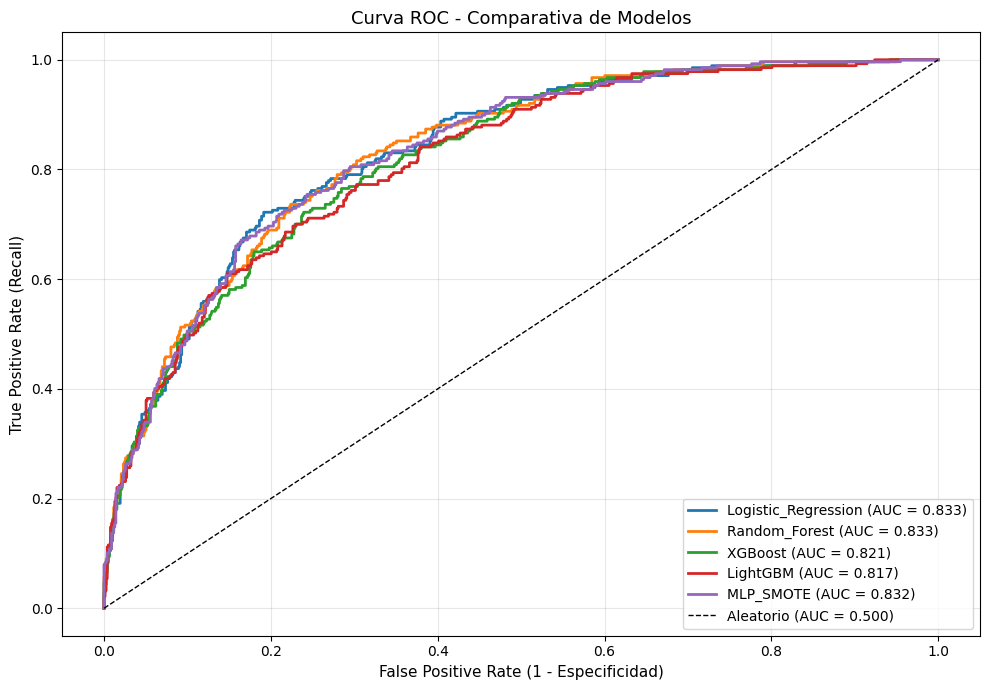


GRÁFICO COMPARATIVO DE MÉTRICAS


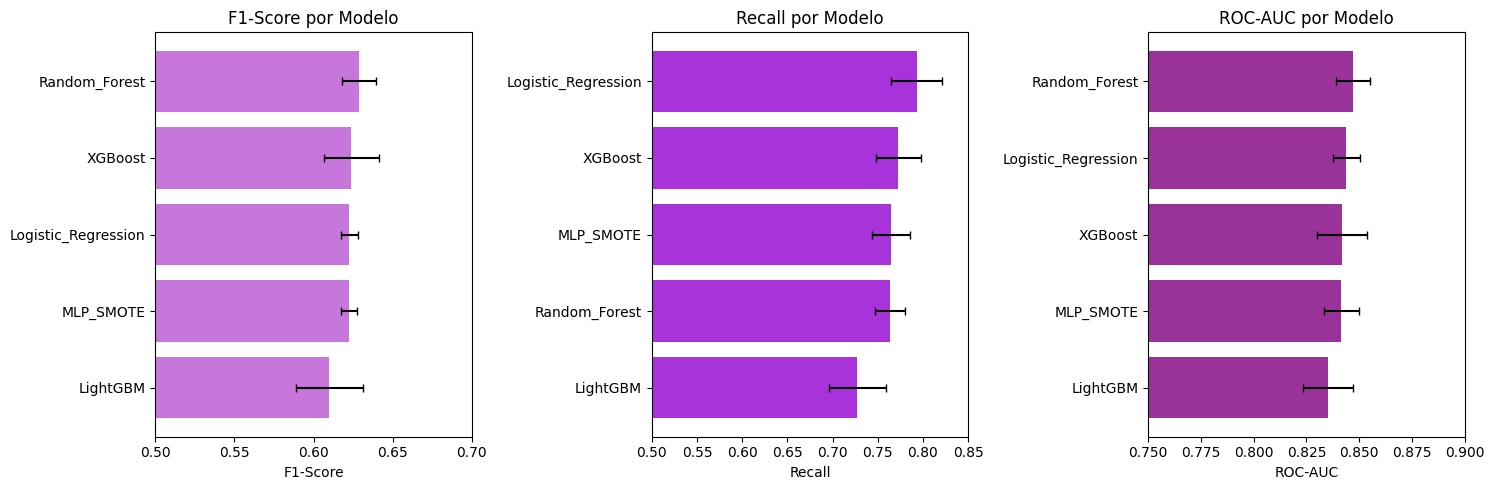

Resultados exportados a:
   - cv_results.csv
   - comparison_results.csv


In [146]:
print("\n" + "=" * 70)
print("CURVA ROC - TODOS LOS MODELOS")
print("=" * 70)

plt.figure(figsize=(10, 7))

colors = sns.color_palette('tab10', n_colors=len(pipelines_fitted))

for (name, pipeline), color in zip(pipelines_fitted.items(), colors):
    if hasattr(pipeline, "predict_proba"):
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_val_proba)
        auc = roc_auc_score(y_val, y_val_proba)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Especificidad)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('Curva ROC - Comparativa de Modelos', fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("imgs/Curva_ROC_AUC_Mean_CV.png")
plt.show()




print("\n" + "=" * 70)
print("GRÁFICO COMPARATIVO DE MÉTRICAS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))



ax1 = axes[0]
models_sorted = cv_df.sort_values("CV_F1_Mean", ascending=True)
ax1.barh(models_sorted["Modelo"], models_sorted["CV_F1_Mean"], xerr=models_sorted["CV_F1_Std"],
         color='mediumorchid', alpha=0.8, capsize=3)
ax1.set_xlabel('F1-Score')
ax1.set_title('F1-Score por Modelo')
ax1.set_xlim(0.5, 0.7)



ax2 = axes[1]
models_sorted = cv_df.sort_values("CV_Recall_Mean", ascending=True)
ax2.barh(models_sorted["Modelo"], models_sorted["CV_Recall_Mean"], xerr=models_sorted["CV_Recall_Std"],
         color='darkviolet', alpha=0.8, capsize=3)
ax2.set_xlabel('Recall')
ax2.set_title('Recall por Modelo')
ax2.set_xlim(0.5, 0.85)



ax3 = axes[2]
models_sorted = cv_df.sort_values("CV_ROC_AUC_Mean", ascending=True)
ax3.barh(models_sorted["Modelo"], models_sorted["CV_ROC_AUC_Mean"], xerr=models_sorted["CV_ROC_AUC_Std"],
         color='purple', alpha=0.8, capsize=3)
ax3.set_xlabel('ROC-AUC')
ax3.set_title('ROC-AUC por Modelo')
ax3.set_xlim(0.75, 0.90)

plt.savefig("imgs/comparativo_de_métricas_CV.png")
plt.tight_layout()
plt.show()




cv_df_export = cv_df[["Modelo", "CV_F1_Mean", "CV_F1_Std", "CV_Recall_Mean", "CV_Recall_Std",
                       "CV_Precision_Mean", "CV_Precision_Std", "CV_ROC_AUC_Mean", "CV_ROC_AUC_Std"]]
cv_df_export.to_csv("cv_results.csv", index=False)
comparison_df.to_csv("comparison_results.csv", index=False)

print("Resultados exportados a:")
print("   - cv_results.csv")
print("   - comparison_results.csv")


In [145]:
  print("\n" + "=" * 70)
print("PRÓXIMOS PASOS")
print("=" * 70)

print("\n1. Evaluación Final en Test Set:")
print("   - Usar el modelo ganador para caso de estudio: {best_recall_model['Modelo']}")
print("   - Evaluar métricas finales en X_test / y_test")
print("   - Reportar resultados finales al stakeholder")

print("\n2. Feature Importance:")
print("   - Analizar feature importance del modelo ganador")
print("   - Identificar drivers clave del churn")
print("   - Usar insights para estrategias de retención")

print("\n3. Despliegue del Modelo:")
print("   - Serializar el modelo ganador con joblib/pickle")
print("   - Crear API REST con FastAPI/Flask")
print("   - Integrar con sistema de monitoreo")

print("\n4. Monitoreo Continuo:")
print("   - Monitorear drift de datos")
print("   - Monitorear degradación del modelo")
print("   - Establecer alertas para re-entrenamiento")

print("\n5. Mejora Continua:")
print("   - Probar ensemble de modelos (Voting/Stacking)")
print("   - Explorar técnicas avanzadas")
print("   - Realizar A/B testing en producción")

print("\n" + "=" * 70)
print("✓ FIN DEL ANÁLISIS - VALIDACIÓN CRUZADA COMPLETA")
print("=" * 70)


PRÓXIMOS PASOS

1. Evaluación Final en Test Set:
   - Usar el modelo ganador para caso de estudio: {best_recall_model['Modelo']}
   - Evaluar métricas finales en X_test / y_test
   - Reportar resultados finales al stakeholder

2. Feature Importance:
   - Analizar feature importance del modelo ganador
   - Identificar drivers clave del churn
   - Usar insights para estrategias de retención

3. Despliegue del Modelo:
   - Serializar el modelo ganador con joblib/pickle
   - Crear API REST con FastAPI/Flask
   - Integrar con sistema de monitoreo

4. Monitoreo Continuo:
   - Monitorear drift de datos
   - Monitorear degradación del modelo
   - Establecer alertas para re-entrenamiento

5. Mejora Continua:
   - Probar ensemble de modelos (Voting/Stacking)
   - Explorar técnicas avanzadas
   - Realizar A/B testing en producción

✓ FIN DEL ANÁLISIS - VALIDACIÓN CRUZADA COMPLETA


# **EVALUACIÓN FINAL**

PARTE 1: EVALUACIÓN FINAL EN TEST SET

Modelo Seleccionado: Logistic Regression
Razón: Mejor Recall para detectar clientes en riesgo de Churn

Preparando modelo final...
Datos de entrenamiento completo: 5964 muestras
Datos de test: 1053 muestras
✅ Modelo entrenado con Train + Validation

----------------------------------------------------------------------
EVALUACIÓN EN TEST SET
----------------------------------------------------------------------

Métricas Finales en Test Set:
   Accuracy:   0.7616
   Recall:     0.8165
   Precision:  0.5316
   F1-Score:   0.6440
   ROC-AUC:    0.8539

Classification Report Completo:
              precision    recall  f1-score   support

    No Churn       0.92      0.74      0.82       775
       Churn       0.53      0.82      0.64       278

    accuracy                           0.76      1053
   macro avg       0.73      0.78      0.73      1053
weighted avg       0.82      0.76      0.77      1053



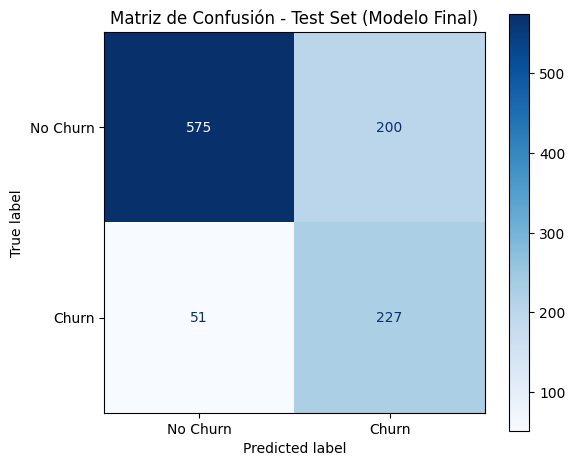


Desglose Matriz de Confusión:
--------------------------------------------------
   True Negative (TN):   575 → Clientes que se quedan, predichos correctamente
   False Positive (FP):  200 → Clientes que se quedan, predichos como churn
   False Negative (FN):   51 → Clientes que se van, predichos como que se quedan ⚠️
   True Positive (TP):   227 → Clientes que se van, predichos correctamente
--------------------------------------------------

Métricas de Negocio:
   Tasa de Detección de Churn:    81.7% (227 de 278 clientes)
   Tasa de Falsas Alarmas:        25.8% (200 de 775 clientes)
   Precisión en Predicciones Churn: 53.2%


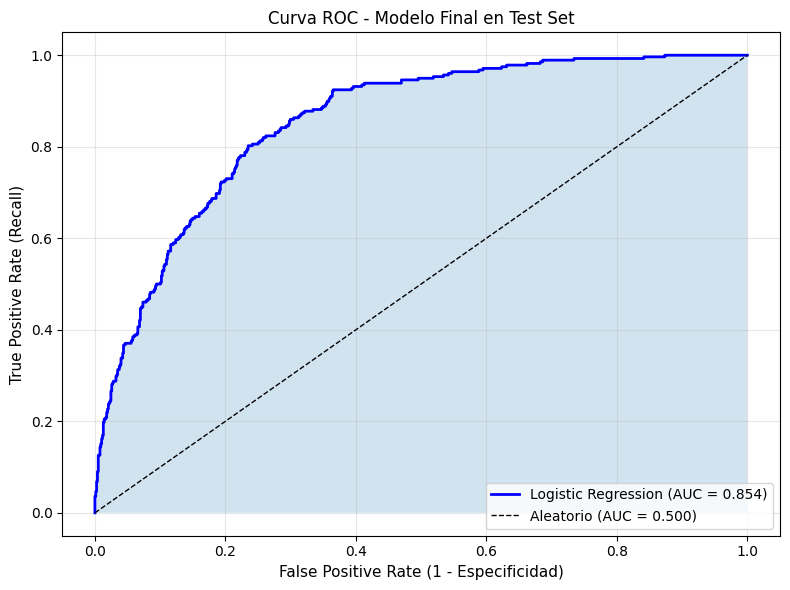

In [147]:
print("=" * 70)
print("PARTE 1: EVALUACIÓN FINAL EN TEST SET")
print("=" * 70)
print("\nModelo Seleccionado: Logistic Regression")
print("Razón: Mejor Recall para detectar clientes en riesgo de Churn")
print("=" * 70)




print("\nPreparando modelo final...")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

print(f"Datos de entrenamiento completo: {X_train_full.shape[0]} muestras")
print(f"Datos de test: {X_test.shape[0]} muestras")

champion_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        C=0.1,
        penalty='l2',
        class_weight='balanced',
        solver='lbfgs',
        random_state=5
    ))
])

champion_model.fit(X_train_full, y_train_full)

print("✅ Modelo entrenado con Train + Validation")




print("\n" + "-" * 70)
print("EVALUACIÓN EN TEST SET")
print("-" * 70)

y_test_pred = champion_model.predict(X_test)
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nMétricas Finales en Test Set:")
print(f"   Accuracy:   {test_acc:.4f}")
print(f"   Recall:     {test_recall:.4f}")
print(f"   Precision:  {test_precision:.4f}")
print(f"   F1-Score:   {test_f1:.4f}")
print(f"   ROC-AUC:    {test_roc_auc:.4f}")

# Classification Report
print("\nClassification Report Completo:")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión - Test Set (Modelo Final)', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig("imgs/matriz_confusion_modelo_final_RL.png")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("\nDesglose Matriz de Confusión:")
print("-" * 50)
print(f"   True Negative (TN):  {tn:4d} → Clientes que se quedan, predichos correctamente")
print(f"   False Positive (FP): {fp:4d} → Clientes que se quedan, predichos como churn")
print(f"   False Negative (FN): {fn:4d} → Clientes que se van, predichos como que se quedan ⚠️")
print(f"   True Positive (TP):  {tp:4d} → Clientes que se van, predichos correctamente")
print("-" * 50)

print("\nMétricas de Negocio:")
print(f"   Tasa de Detección de Churn:    {test_recall*100:.1f}% ({tp} de {tp+fn} clientes)")
print(f"   Tasa de Falsas Alarmas:        {fp/(tn+fp)*100:.1f}% ({fp} de {tn+fp} clientes)")
print(f"   Precisión en Predicciones Churn: {test_precision*100:.1f}%")

plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate (1 - Especificidad)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('Curva ROC - Modelo Final en Test Set', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("imgs/Curva_Roc_Modelo_final_RL")
plt.show()


PARTE 2: FEATURE IMPORTANCE

Total de features después de preprocesamiento: 24

TOP 15 FEATURES MÁS IMPORTANTES:
----------------------------------------------------------------------
   Contract_Two year                   | Coef: -1.1825 | ↓ Disminuye Churn
   tenure                              | Coef: -1.1315 | ↓ Disminuye Churn
   Contract_One year                   | Coef: -0.6651 | ↓ Disminuye Churn
   InternetService_No                  | Coef: -0.4570 | ↓ Disminuye Churn
   Total                               | Coef: +0.4433 | ↑ Aumenta Churn
   InternetService_Fiber optic         | Coef: +0.4382 | ↑ Aumenta Churn
   Monthly                             | Coef: +0.4345 | ↑ Aumenta Churn
   PhoneService_Yes                    | Coef: -0.4096 | ↓ Disminuye Churn
   OnlineSecurity_Yes                  | Coef: -0.4052 | ↓ Disminuye Churn
   MultipleLines_No phone service      | Coef: +0.3819 | ↑ Aumenta Churn
   PaymentMethod_Electronic check      | Coef: +0.3773 | ↑ Aumenta Churn


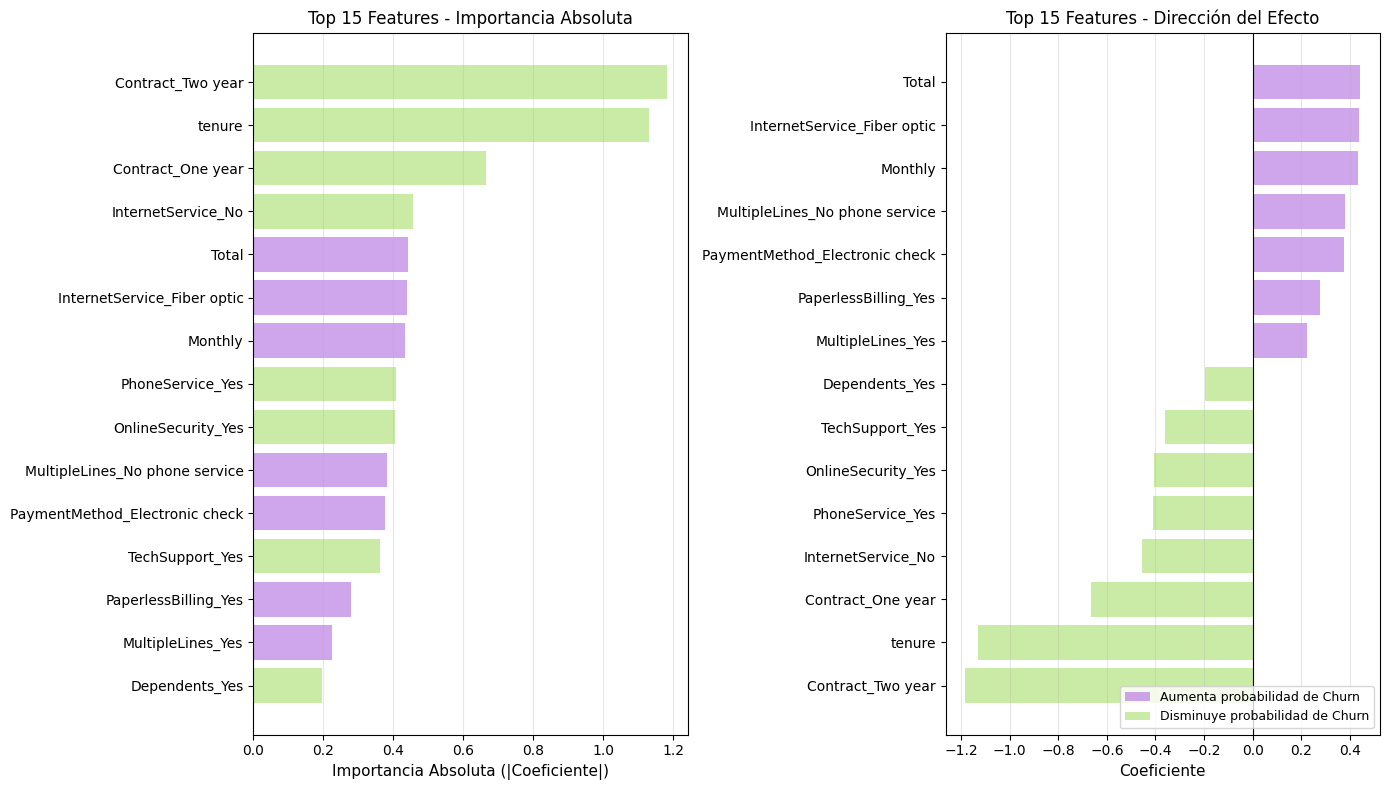


💡 INSIGHTS - DRIVERS CLAVE DEL CHURN

🔴 FACTORES QUE AUMENTAN EL CHURN (Coeficiente Positivo):
   • Total: +0.4433
   • InternetService_Fiber optic: +0.4382
   • Monthly: +0.4345
   • MultipleLines_No phone service: +0.3819
   • PaymentMethod_Electronic check: +0.3773

🟢 FACTORES QUE DISMINUYEN EL CHURN (Coeficiente Negativo):
   • Contract_Two year: -1.1825
   • tenure: -1.1315
   • Contract_One year: -0.6651
   • InternetService_No: -0.4570
   • PhoneService_Yes: -0.4096

----------------------------------------------------------------------
ESTRATEGIAS DE RETENCIÓN RECOMENDADAS:
----------------------------------------------------------------------

1. CONTRATOS A LARGO PLAZO:
   - Ofrecer incentivos para contratos de 1-2 años
   - Descuentos por permanencia

2. CLIENTES CON FIBRA ÓPTICA:
   - Monitorear satisfacción del servicio
   - Ofrecer mejoras o descuentos preventivos

3. CLIENTES NUEVOS (Tenure bajo):
   - Programa de onboarding mejorado
   - Seguimiento proactivo en primer

In [151]:
print("\n" + "=" * 70)
print("PARTE 2: FEATURE IMPORTANCE")
print("=" * 70)


feature_names = []


feature_names.extend(numeric_features)


cat_encoder = champion_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(cat_features)

print(f"\nTotal de features después de preprocesamiento: {len(feature_names)}")


coefficients = champion_model.named_steps['classifier'].coef_[0]


feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})


feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)


print("\nTOP 15 FEATURES MÁS IMPORTANTES:")
print("-" * 70)
top_15 = feature_importance.head(15)
for idx, row in top_15.iterrows():
    direction = "↑ Aumenta Churn" if row['Coefficient'] > 0 else "↓ Disminuye Churn"
    print(f"   {row['Feature']:<35} | Coef: {row['Coefficient']:+.4f} | {direction}")


fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ax1 = axes[0]
top_15_plot = feature_importance.head(15).sort_values('Abs_Coefficient', ascending=True)
colors = ['#BB7FE3' if c > 0 else '#B4E37F' for c in top_15_plot['Coefficient']]
ax1.barh(top_15_plot['Feature'], top_15_plot['Abs_Coefficient'], color=colors, alpha=0.7)
ax1.set_xlabel('Importancia Absoluta (|Coeficiente|)', fontsize=11)
ax1.set_title('Top 15 Features - Importancia Absoluta', fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')


ax2 = axes[1]
top_15_dir = feature_importance.head(15).sort_values('Coefficient', ascending=True)
colors_dir = ['#BB7FE3' if c > 0 else '#B4E37F' for c in top_15_dir['Coefficient']]
ax2.barh(top_15_dir['Feature'], top_15_dir['Coefficient'], color=colors_dir, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Coeficiente', fontsize=11)
ax2.set_title('Top 15 Features - Dirección del Efecto', fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')


legend_elements = [Patch(facecolor='#BB7FE3', alpha=0.7, label='Aumenta probabilidad de Churn'),
                   Patch(facecolor='#B4E37F', alpha=0.7, label='Disminuye probabilidad de Churn')]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("imgs/importancia_variables.png")
plt.show()


print("\n" + "=" * 70)
print("💡 INSIGHTS - DRIVERS CLAVE DEL CHURN")
print("=" * 70)

print("\n🔴 FACTORES QUE AUMENTAN EL CHURN (Coeficiente Positivo):")
aumentan_churn = feature_importance[feature_importance['Coefficient'] > 0].head(5)
for idx, row in aumentan_churn.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:+.4f}")

print("\n🟢 FACTORES QUE DISMINUYEN EL CHURN (Coeficiente Negativo):")
disminuyen_churn = feature_importance[feature_importance['Coefficient'] < 0].sort_values('Coefficient').head(5)
for idx, row in disminuyen_churn.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:+.4f}")

print("\n" + "-" * 70)
print("ESTRATEGIAS DE RETENCIÓN RECOMENDADAS:")
print("-" * 70)

print("""
1. CONTRATOS A LARGO PLAZO:
   - Ofrecer incentivos para contratos de 1-2 años
   - Descuentos por permanencia

2. CLIENTES CON FIBRA ÓPTICA:
   - Monitorear satisfacción del servicio
   - Ofrecer mejoras o descuentos preventivos

3. CLIENTES NUEVOS (Tenure bajo):
   - Programa de onboarding mejorado
   - Seguimiento proactivo en primeros 6 meses

4. CLIENTES SIN SERVICIOS ADICIONALES:
   - Ofrecer paquetes de servicios (Security, Backup, Support)
   - Promociones cruzadas

5. FACTURACIÓN ELECTRÓNICA:
   - Revisar experiencia de usuario
   - Ofrecer múltiples opciones de pago
""")

In [154]:
print("\n" + "=" * 70)
print("PARTE 3: DESPLIEGUE DEL MODELO")
print("=" * 70)

modelo_path = "champion_model"

os.makedirs(modelo_path, exist_ok=True)

with open(f'{modelo_path}/churn_model_final.pkl', 'wb') as f:
    pickle.dump(champion_model, f)

print(f"Modelo serializado exitosamente: churn_model_final.pkl")

model_info = {
    'model_name': 'Logistic Regression Churn Predictor',
    'version': '1.0',
    'date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'features': feature_names,
    'metrics_test': {
        'accuracy': test_acc,
        'recall': test_recall,
        'precision': test_precision,
        'f1_score': test_f1,
        'roc_auc': test_roc_auc
    },
    'config': {
        'C': 0.1,
        'penalty': 'l2',
        'class_weight': 'balanced',
        'solver': 'lbfgs'
    }
}

with open(f'{modelo_path}/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("Información del modelo guardada: model_info.pkl")


PARTE 3: DESPLIEGUE DEL MODELO
Modelo serializado exitosamente: churn_model_final.pkl
Información del modelo guardada: model_info.pkl


In [157]:
print("\n" + "=" * 70)
print("REPORTE EJECUTIVO AUTOMÁTICO - MODELO CHURN")
print("=" * 70)




metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Recall", "Precision", "F1-Score", "ROC-AUC"],
    "Valor": [
        test_acc,
        test_recall,
        test_precision,
        test_f1,
        test_roc_auc
    ]
})

metrics_df["Valor (%)"] = metrics_df["Valor"].apply(lambda x: f"{x:.2%}")

print("\n MÉTRICAS EN TEST SET")
print(metrics_df[["Métrica", "Valor (%)"]].to_string(index=False))






business_summary = pd.DataFrame({
    "Indicador": [
        "Clientes que se van detectados correctamente",
        "Clientes marcados como riesgo que realmente se van"
    ],
    "Resultado": [
        f"{test_recall*100:.1f}%",
        f"{test_precision*100:.1f}%"
    ]
})

print("\nINTERPRETACIÓN DE NEGOCIO")
print(business_summary.to_string(index=False))





top_positive = feature_importance.sort_values("Coefficient", ascending=False).head(5)
top_negative = feature_importance.sort_values("Coefficient").head(5)

print("\n🔴 TOP 5 FACTORES QUE AUMENTAN EL CHURN")
print(top_positive[["Feature", "Coefficient"]].to_string(index=False))

print("\n🟢 TOP 5 FACTORES QUE DISMINUYEN EL CHURN")
print(top_negative[["Feature", "Coefficient"]].to_string(index=False))






recommendations_df = pd.DataFrame({
    "Recomendación Estratégica": [
        "Implementar modelo en CRM para scoring diario",
        "Generar alertas para clientes con probabilidad > 60%",
        "Diseñar campañas para contratos Month-to-month",
        "Ofrecer incentivos a clientes de alto gasto",
        "Monitorear desempeño mensualmente",
        "Reentrenar modelo trimestralmente"
    ]
})

print("\nRECOMENDACIONES")
print(recommendations_df.to_string(index=False))




executive_summary = pd.DataFrame({
    "Modelo": ["Logistic Regression (class_weight='balanced')"],
    "Fecha": [pd.Timestamp.now().strftime('%Y-%m-%d')],
    "Recall (%)": [f"{test_recall*100:.1f}%"],
    "Precision (%)": [f"{test_precision*100:.1f}%"],
    "ROC-AUC (%)": [f"{test_roc_auc*100:.1f}%"]
})

print("\n RESUMEN EJECUTIVO")
print(executive_summary.to_string(index=False))


print("\n" + "=" * 70)
print("PROYECTO COMPLETADO - MODELO LISTO PARA PRODUCCIÓN")
print("=" * 70)


REPORTE EJECUTIVO AUTOMÁTICO - MODELO CHURN

 MÉTRICAS EN TEST SET
  Métrica Valor (%)
 Accuracy    76.16%
   Recall    81.65%
Precision    53.16%
 F1-Score    64.40%
  ROC-AUC    85.39%

INTERPRETACIÓN DE NEGOCIO
                                         Indicador Resultado
      Clientes que se van detectados correctamente     81.7%
Clientes marcados como riesgo que realmente se van     53.2%

🔴 TOP 5 FACTORES QUE AUMENTAN EL CHURN
                       Feature  Coefficient
                         Total     0.443278
   InternetService_Fiber optic     0.438227
                       Monthly     0.434474
MultipleLines_No phone service     0.381942
PaymentMethod_Electronic check     0.377289

🟢 TOP 5 FACTORES QUE DISMINUYEN EL CHURN
           Feature  Coefficient
 Contract_Two year    -1.182485
            tenure    -1.131496
 Contract_One year    -0.665119
InternetService_No    -0.457003
  PhoneService_Yes    -0.409621

RECOMENDACIONES
                           Recomendación Estrat